# Minimal BESS model example

This notebook shows a first, minimal usage of the `src` battery sizing API for both the `Optimizer` and `Simulator` classes.

How to use:
1. Run cell 1 (imports).
2. Edit cell 2 (choose your simulation parameters).
3. Run the remaining cells.

Important: in `Optimizer`, `battery_power_capacity` and `battery_energy_capacity` are optimized **endogenously**. You provide assumptions and bounds, not fixed capacities. Instead in the `Simulator` you have to provide **exogenously** the battery sizing paramaters and the simulation determines the system performance.

In [11]:
from pathlib import Path
import sys

import numpy as np

# Ensure repository root is on sys.path when running from notebooks/.
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.bess_optimizer import Optimizer
from src.bess_simulator import Simulator

print(f"Using repo root: {repo_root}")

Using repo root: c:\Users\Pc\Documents\GitHub\optimal_battery_sizing


## Battery Optimizer - Usage 

In [12]:
# USER INPUTS: set your simulation parameters here.

# Solar assumptions
solar_capacity_mw = 300.0
solar_profile = np.array([
    0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
    0.10, 0.30, 0.50, 0.70, 0.85, 0.95,
    0.98, 0.95, 0.88, 0.75, 0.55, 0.30,
    0.10, 0.00, 0.00, 0.00, 0.00, 0.00,
], dtype=float)

# Load assumptions (MW)
demand_mw = np.array([
    50, 45, 40, 38, 36, 38, 45, 60,
    75, 85, 90, 92, 90, 88, 86, 88,
    92, 95, 90, 80, 70, 65, 58, 52,
], dtype=float)

# Battery assumptions (capacities remain endogenous)
efficiency = 0.90
battery_power_cost = 200_000.0
battery_energy_cost = 300_000.0
max_battery_power = 500.0
max_hours = 8.0

# Optional model settings
solver_name = "highs"
unmet_penalty = 1e9

In [13]:
# Define and solve the optimization model
model = Optimizer(solver_name=solver_name, unmet_penalty=unmet_penalty)
model.add_solar(capacity=solar_capacity_mw, profile=solar_profile)
model.add_storage(
    efficiency=efficiency,
    battery_power_cost=battery_power_cost,
    battery_energy_cost=battery_energy_cost,
    max_battery_power=max_battery_power,
    max_hours=max_hours,
)
model.add_load(demand=demand_mw)
model.solve()
results = model.get_results()

In [14]:
# Print results
duration_hours = results["battery_energy_capacity"] / max(results["battery_power_capacity"], 1e-9)
print("=== Optimized Battery Size ===")
print(f"Power capacity (MW):    {results['battery_power_capacity']:.3f}")
print(f"Energy capacity (MWh):  {results['battery_energy_capacity']:.3f}")
print(f"Duration (h):           {duration_hours:.3f}")
print(f"Objective value:        {results['objective_value']:.2f}")
print()
print("=== System Performance ===")
print(f"Solar generation:         {results['sol'].sum():.2f} MWh")
print(f"Battery discharge:        {results['s_discharge'].sum():.2f} MWh")
print(f"Battery charge:           {results['s_charge'].sum():.2f} MWh")
print(f"Total unmet load (MWh):   {results['total_unmet']:.2f} MWh")

=== Optimized Battery Size ===
Power capacity (MW):    85.909
Energy capacity (MWh):  687.268
Duration (h):           8.000
Objective value:        223362212.06

=== System Performance ===
Solar generation:         1720.44 MWh
Battery discharge:        652.00 MWh
Battery charge:           724.44 MWh
Total unmet load (MWh):   0.00 MWh


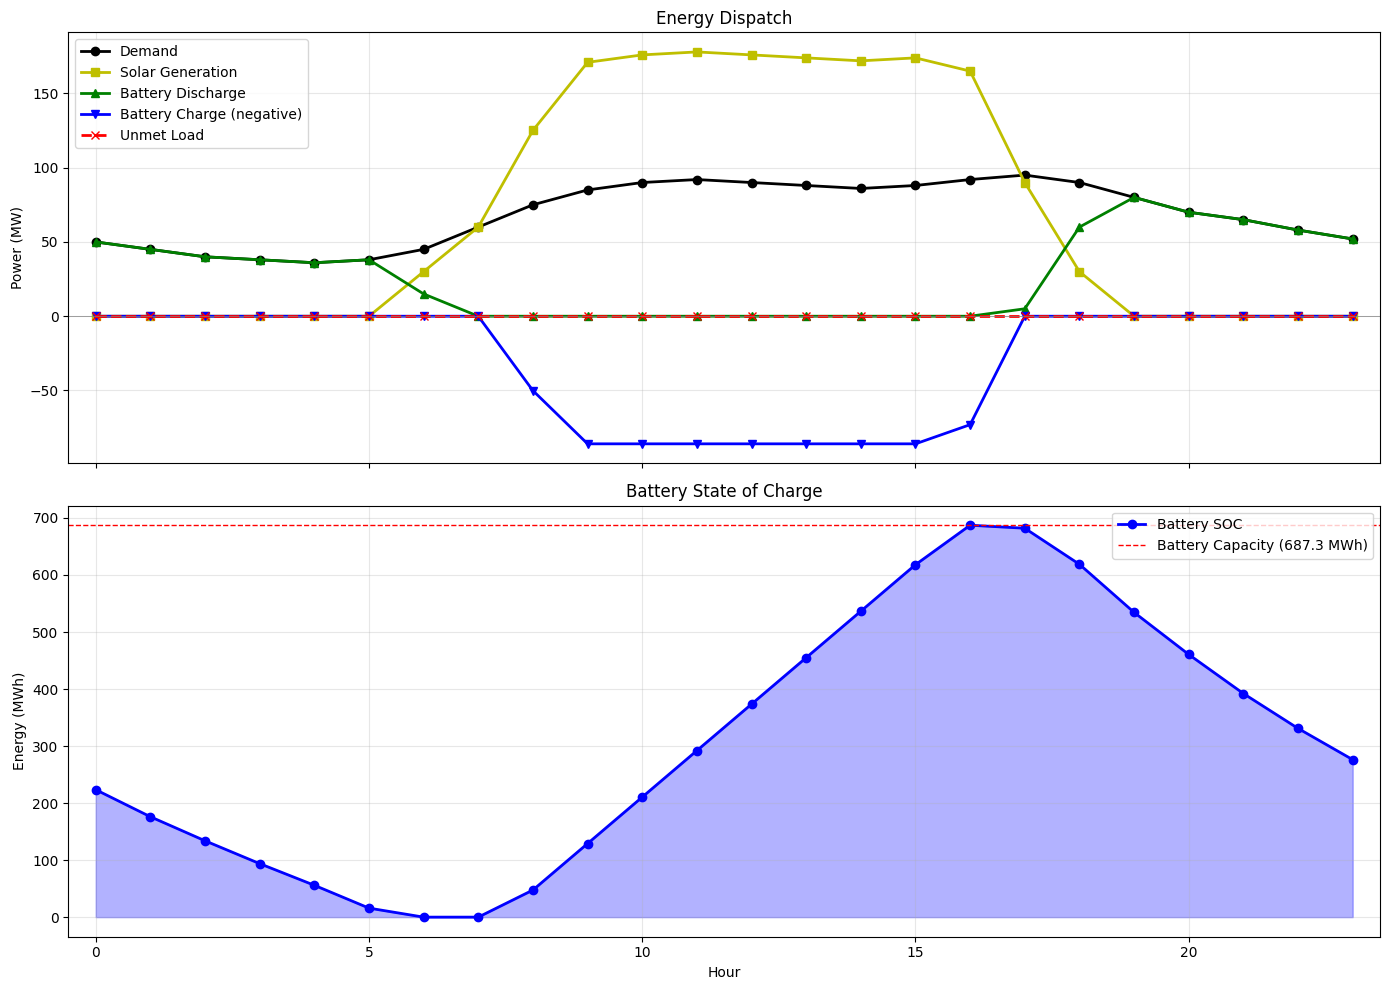

In [15]:
# Plot results
_ = model.plot_dispatch(show=False)

## Next edits for experiments

- Change `solar_profile` and `demand_mw` to your scenario data.
- Tune economics (`battery_power_cost`, `battery_energy_cost`).
- Tune constraints (`max_battery_power`, `max_hours`, `efficiency`).
- Keep capacities endogenous by not passing fixed capacities into the optimization workflow.

## Battery Simulation - Usage

Keep same parameters as the battery `Optimizer` but needs the decision variables `battery_power_capacity` and `battery_energy_capacity` to be defined.

In [16]:
# Fixed sizign decision variables
battery_power_capacity = 100.0      # MW
battery_energy_capacity = 800.0    # MWh

In [17]:
# Define and solve the simulation model
model = Simulator(battery_power_capacity, battery_energy_capacity, efficiency=efficiency)
model.add_solar(capacity=solar_capacity_mw, profile=solar_profile)
model.add_load(demand=demand_mw)
model.simulate()
results = model.get_results()

In [18]:
# Print results
duration_hours = results["battery_energy_capacity"] / max(results["battery_power_capacity"], 1e-9)
print("=== Optimized Battery Size ===")
print(f"Power capacity (MW):  {results['battery_power_capacity']:.3f}")
print(f"Energy capacity (MWh): {results['battery_energy_capacity']:.3f}")
print(f"Duration (h):          {duration_hours:.3f}")
print()
print("=== System Performance ===")
print(f"Solar generation:         {results['sol'].sum():.2f} MWh")
print(f"Battery discharge:        {results['s_discharge'].sum():.2f} MWh")
print(f"Battery charge:           {results['s_charge'].sum():.2f} MWh")
print(f"Total unmet load (MWh):   {results['total_unmet']:.2f} MWh")


=== Optimized Battery Size ===
Power capacity (MW):  100.000
Energy capacity (MWh): 800.000
Duration (h):          8.000

=== System Performance ===
Solar generation:         1839.27 MWh
Battery discharge:        390.00 MWh
Battery charge:           843.27 MWh
Total unmet load (MWh):   262.00 MWh
